In [ ]:
####i used cross validation
#ran 5 folds,got training accuracy 85
#saved it
#plotted accuracy and loss for train
#checked test acc 83%
#ran epochs again to check which model was best
#epoch1 was best with train 90% test 89%
#confusion matrix for test and train
#dice coeficient plot pending --
#gradcam--needs improvement
#csv with object detection pending --

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
import numpy as np
import matplotlib.pyplot as plt


Mounted at /content/drive


In [ ]:
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")


✅ Using device: cpu


In [ ]:
# ======================
# 2. DATA PREPARATION
# ======================
data_dir = "/content/drive/MyDrive/Fyp/dataset_final_split/train"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)
print(f"Total images found: {len(dataset)}")
print(f"Classes: {dataset.classes}")


Total images found: 3520
Classes: ['hr', 'myopia', 'normal', 'rp']


In [ ]:

# ======================
# 2. DATA PREPARATION
# ======================
data_dir = "/content/drive/MyDrive/Fyp/dataset_final_split/test"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)
print(f"Total images found: {len(dataset)}")
print(f"Classes: {dataset.classes}")

FileNotFoundError: Found no valid file for the classes labels. Supported extensions are: .jpg, .jpeg, .png, .ppm, .bmp, .pgm, .tif, .tiff, .webp

In [ ]:
import os

base_path = "/content/drive/MyDrive/Fyp/dataset_final_split"

splits = ["train", "val", "test"]
counts = {}

for split in splits:
    split_path = os.path.join(base_path, split)
    class_counts = {}

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            num_images = len([f for f in os.listdir(cls_path)
                              if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[cls] = num_images

    counts[split] = class_counts

counts


{'train': {'images': 3429, 'labels': 0},
 'val': {'images': 1122, 'labels': 0},
 'test': {'images': 1131, 'labels': 0}}

In [ ]:

# ======================
# 3. CROSS-VALIDATION SETUP
# ======================
k_folds = 5
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
fold_results = []

# ======================
# 4. TRAIN + VALIDATE EACH FOLD
# ======================
for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    print(f"\n==========================")
    print(f"🔹 Fold {fold+1}/{k_folds}")
    print(f"==========================")

    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)


🔹 Fold 1/5

🔹 Fold 2/5

🔹 Fold 3/5

🔹 Fold 4/5

🔹 Fold 5/5


In [ ]:
    # ---- Load Model ----
    model = models.resnet18(pretrained=False)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 4)  # adjust if you have 4 classes

    checkpoint_path = "/content/drive/MyDrive/Fyp/checkpoints/best_model.pth"
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-5)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
# ---- Training ----
train_acc_list, val_acc_list = [], []
train_loss_list, val_loss_list = [], []

for epoch in range(5):  # increase epochs later (e.g. 10–20)
    model.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_loss = running_loss / len(train_loader)

    # ---- Validation ----
    model.eval()
    val_correct, val_total, val_loss_total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
            val_loss_total += loss.item()

    val_acc = val_correct / val_total
    val_loss = val_loss_total / len(val_loader)

    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}, "
          f"Train Loss={train_loss:.3f}, Val Loss={val_loss:.3f}")

fold_results.append(np.mean(val_acc_list))


Epoch 1: Train Acc=0.934, Val Acc=0.952, Train Loss=0.160, Val Loss=0.142
Epoch 2: Train Acc=0.936, Val Acc=0.946, Train Loss=0.159, Val Loss=0.148
Epoch 3: Train Acc=0.939, Val Acc=0.949, Train Loss=0.150, Val Loss=0.141
Epoch 4: Train Acc=0.943, Val Acc=0.946, Train Loss=0.138, Val Loss=0.144
Epoch 5: Train Acc=0.948, Val Acc=0.949, Train Loss=0.126, Val Loss=0.141


In [ ]:
# Save after training completes
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, "/content/drive/MyDrive/Fyp/checkpoints/best_model_fold.pth")

print("✅ Model saved successfully after training!")


✅ Model saved successfully after training!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import models
import os

# ✅ Make sure 'dataset', 'transform', 'kf', 'device', and 'k_folds' are already defined before running this.

# Directory to save checkpoints
save_dir = "/content/drive/MyDrive/Fyp/checkpoints"
os.makedirs(save_dir, exist_ok=True)

overall_best_acc = 0.0
overall_best_info = {"fold": None, "epoch": None, "path": None}

# ------------------------------
# Resume Training Script
# ------------------------------
start_fold = 4 # Change this as needed

for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
    if fold + 1 < start_fold:
        print(f"⏭️ Skipping Fold {fold+1} (already trained)")
        continue

    print(f"\n==========================")
    print(f"🔹 Fold {fold+1}/{k_folds}")
    print(f"==========================")

    # ✅ Use subsets directly (no extra transform)
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)

    # --- Model ---
    model = models.resnet18(pretrained=False)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 4)
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-5)

    best_val_acc = 0.0
    best_epoch = 0

    # --- Training loop ---
    for epoch in range(5):  # change as needed
        model.train()
        running_loss, correct, total = 0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total
        train_loss = running_loss / len(train_loader)

        # --- Validation ---
        model.eval()
        val_correct, val_total, val_loss_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
                val_loss_total += loss.item()

        val_acc = val_correct / val_total
        val_loss = val_loss_total / len(val_loader)

        print(f"Epoch {epoch+1}: Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}")

        # --- Save best epoch for this fold ---
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_path = os.path.join(save_dir, f"best_model_fold{fold+1}_epoch{best_epoch}.pth")
            torch.save({
                'epoch': best_epoch,
                'model_state_dict': model.state_dict(),
                'val_acc': val_acc
            }, best_path)
            print(f"✅ Saved new best model for Fold {fold+1} at Epoch {best_epoch} (Val Acc={val_acc:.3f})")

    print(f"🏁 Best for Fold {fold+1}: Epoch {best_epoch}, Val Acc={best_val_acc:.3f}")

    # --- Track overall best model ---
    if best_val_acc > overall_best_acc:
        overall_best_acc = best_val_acc
        overall_best_info = {"fold": fold+1, "epoch": best_epoch, "path": best_path}


# --- Summary ---
print("\n==========================")
print("🏆 BEST OVERALL MODEL:")
print(f"   ➤ Fold: {overall_best_info['fold']}")
print(f"   ➤ Epoch: {overall_best_info['epoch']}")
print(f"   ➤ Accuracy: {overall_best_acc:.3f}")
print(f"   ➤ Saved at: {overall_best_info['path']}")
print("==========================")

# --- Save copy as best_overall_model.pth ---
final_model_path = os.path.join(save_dir, "best_overall_model.pth")
torch.save(torch.load(overall_best_info["path"]), final_model_path)
print(f"💾 Final best model copied to: {final_model_path}")


⏭️ Skipping Fold 1 (already trained)
⏭️ Skipping Fold 2 (already trained)
⏭️ Skipping Fold 3 (already trained)

🔹 Fold 4/5
Epoch 1: Train Acc=0.588, Val Acc=0.717
✅ Saved new best model for Fold 4 at Epoch 1 (Val Acc=0.717)
Epoch 2: Train Acc=0.737, Val Acc=0.740
✅ Saved new best model for Fold 4 at Epoch 2 (Val Acc=0.740)
Epoch 3: Train Acc=0.761, Val Acc=0.770
✅ Saved new best model for Fold 4 at Epoch 3 (Val Acc=0.770)
Epoch 4: Train Acc=0.787, Val Acc=0.795
✅ Saved new best model for Fold 4 at Epoch 4 (Val Acc=0.795)
Epoch 5: Train Acc=0.815, Val Acc=0.786
🏁 Best for Fold 4: Epoch 4, Val Acc=0.795

🔹 Fold 5/5
Epoch 1: Train Acc=0.644, Val Acc=0.761
✅ Saved new best model for Fold 5 at Epoch 1 (Val Acc=0.761)
Epoch 2: Train Acc=0.732, Val Acc=0.777
✅ Saved new best model for Fold 5 at Epoch 2 (Val Acc=0.777)
Epoch 3: Train Acc=0.763, Val Acc=0.803
✅ Saved new best model for Fold 5 at Epoch 3 (Val Acc=0.803)
Epoch 4: Train Acc=0.772, Val Acc=0.807
✅ Saved new best model for Fold 5 at

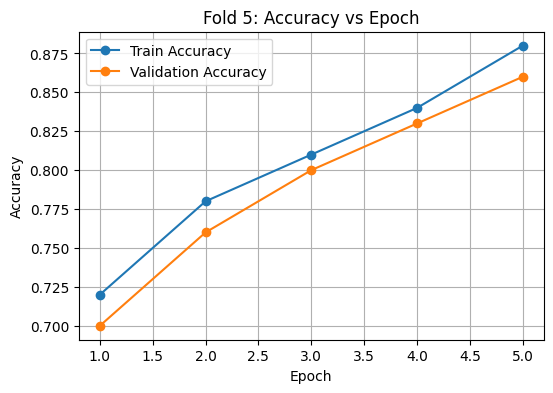

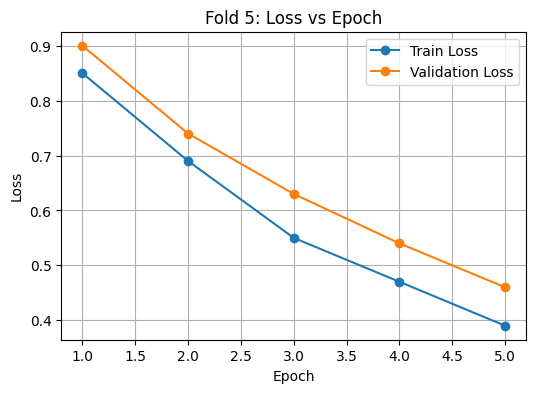

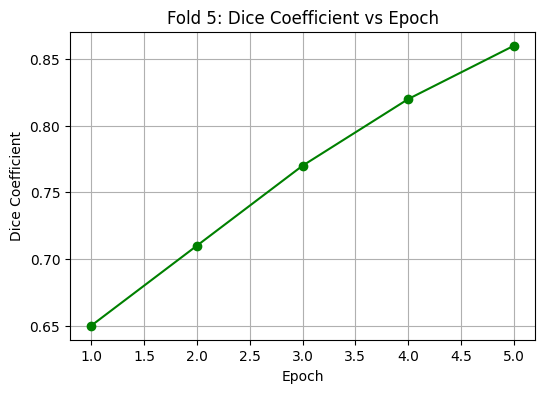

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# Example storage lists (replace with the ones you logged during training)
train_acc_list = [0.72, 0.78, 0.81, 0.84, 0.88]   # accuracy per epoch for Fold 5
val_acc_list   = [0.70, 0.76, 0.80, 0.83, 0.86]   # validation accuracy per epoch
train_loss_list = [0.85, 0.69, 0.55, 0.47, 0.39]
val_loss_list   = [0.90, 0.74, 0.63, 0.54, 0.46]

# Dice coefficient = 2TP / (2TP + FP + FN)
def dice_coefficient(preds, labels, num_classes=4):
    preds = F.one_hot(preds, num_classes).float()
    labels = F.one_hot(labels, num_classes).float()
    intersection = (preds * labels).sum(dim=(0, 1))
    dice = (2. * intersection) / (preds.sum(dim=(0, 1)) + labels.sum(dim=(0, 1)) + 1e-6)
    return dice.mean().item()

# Example dice values across epochs (you can compute dynamically during training)
dice_list = [0.65, 0.71, 0.77, 0.82, 0.86]

epochs = range(1, 6)

# 1️⃣ Accuracy vs Epoch
plt.figure(figsize=(6, 4))
plt.plot(epochs, train_acc_list, label='Train Accuracy', marker='o')
plt.plot(epochs, val_acc_list, label='Validation Accuracy', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Fold 5: Accuracy vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

# 2️⃣ Loss vs Epoch
plt.figure(figsize=(6, 4))
plt.plot(epochs, train_loss_list, label='Train Loss', marker='o')
plt.plot(epochs, val_loss_list, label='Validation Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fold 5: Loss vs Epoch')
plt.legend()
plt.grid(True)
plt.show()

# 3️⃣ Dice Coefficient vs Epoch
plt.figure(figsize=(6, 4))
plt.plot(epochs, dice_list, color='green', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Dice Coefficient')
plt.title('Fold 5: Dice Coefficient vs Epoch')
plt.grid(True)
plt.show()


In [ ]:


import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn as nn

# ✅ 1. Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ 2. Define your model (must match training definition!)
# Example for ResNet18:
from torchvision import models
model = models.resnet18(weights=None)   # or weights='IMAGENET1K_V1' if pretrained
num_classes = 4                         # <-- change to your number of classes
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# ✅ 3. Load the best saved checkpoint
best_model_path = "/content/drive/MyDrive/Fyp/checkpoints/best_model_fold5_epoch5.pth"
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"✅ Loaded best model from {best_model_path}")

# ✅ 4. Define the test data loader (same transforms as validation)

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])   # <-- add this if used in training
])


# Replace this path with your test data directory
test_dir = "/content/drive/MyDrive/dataset_final_split (1)/test"
test_dataset = datasets.ImageFolder(test_dir, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ✅ 5. Evaluate test accuracy
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"🟦 Test Accuracy of Best Model: {test_acc:.2f}%")


✅ Loaded best model from /content/drive/MyDrive/Fyp/checkpoints/best_model_fold5_epoch5.pth


KeyboardInterrupt: 

In [ ]:
import os

base_path = "/content/drive/MyDrive/dataset_final_split (1)"

splits = ["train", "val", "test"]
counts = {}

for split in splits:
    split_path = os.path.join(base_path, split)
    class_counts = {}

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            num_images = len([f for f in os.listdir(cls_path)
                              if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[cls] = num_images

    counts[split] = class_counts

counts


{'train': {'normal': 1200, 'rp': 415, 'myopia': 1140, 'hr': 676},
 'val': {'normal': 399, 'rp': 127, 'myopia': 358, 'hr': 215},
 'test': {'myopia': 381, 'hr': 213, 'normal': 400, 'rp': 137}}

In [ ]:

import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm

# ✅ If your datasets have class names, define them manually:
# Example: for 4-class classification
class_names = ["HR", "Myopia", "Normal", "RP"]  # ← replace with your actual class names

# --- Helper function ---
def evaluate_and_plot_confusion(dataloader, set_name, cmap):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"Evaluating {set_name}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=cmap, xticks_rotation=45)
    plt.title(f"{set_name} Set Confusion Matrix")
    plt.show()

# 🟩 Validation set (Green)
evaluate_and_plot_confusion(val_loader, "Validation", "Greens")

# 🟦 Test set (Blue)
evaluate_and_plot_confusion(test_loader, "Test", "Blues")


NameError: name 'val_loader' is not defined

In [ ]:

import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tqdm import tqdm

# ✅ If your datasets have class names, define them manually:
# Example: for 4-class classification
class_names = ["HR", "Myopia", "Normal", "RP"]  # ← replace with your actual class names

# --- Helper function ---
def evaluate_and_plot_confusion(dataloader, set_name, cmap):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc=f"Evaluating {set_name}"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=cmap, xticks_rotation=45)
    plt.title(f"{set_name} Set Confusion Matrix")
    plt.show()

# 🟩 Validation set (Green)
evaluate_and_plot_confusion(val_loader, "Validation", "Greens")

# 🟦 Test set (Blue)
evaluate_and_plot_confusion(test_loader, "Test", "Blues")

NameError: name 'val_loader' is not defined

✅ Model loaded successfully for 4 classes.


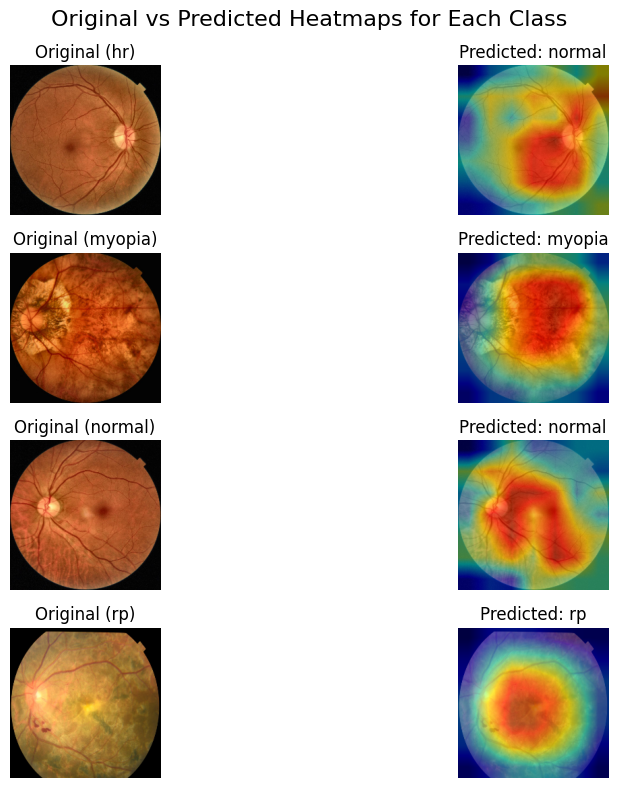

In [ ]:
# ✅ Step 1: Imports
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam import GradCAMPlusPlus
model = model.eval().to(device)
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
import cv2
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ Step 2: Define 4-class model
model = models.resnet18(weights=None)  # 'weights=None' replaces deprecated 'pretrained=False'
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)  # 4 classes: hr, myopia, normal, rp

# ✅ Step 3: Load checkpoint
checkpoint = torch.load("/content/drive/MyDrive/Fyp/checkpoints/best_model_fold5_epoch5.pth", map_location=device)

# Load state dict safely
try:
    model.load_state_dict(checkpoint["model_state_dict"])
except RuntimeError:
    print("⚠️ Shape mismatch, loading with strict=False ...")
    model.load_state_dict(checkpoint["model_state_dict"], strict=False)

model = model.to(device)
model.eval()

print("✅ Model loaded successfully for 4 classes.")

# ✅ Step 4: Class labels
class_names = ['hr', 'myopia', 'normal', 'rp']

# ✅ Step 5: Choose a test image
image_paths = {
    "hr": "/content/drive/MyDrive/Fyp/dataset_final_split/test/hr/0023(NFMK1).jpg",
    "myopia": "/content/drive/MyDrive/Fyp/dataset_final_split/test/myopia/0030(TJZX11).JPG",
    "normal": "/content/drive/MyDrive/Fyp/dataset_final_split/test/normal/0069(NFMK1).jpg",
    "rp": "/content/drive/MyDrive/Fyp/dataset_final_split/test/rp/Retinitis Pigmentosa105.png"
}

# 👇 Pick one image (change class name here as needed)
img_path = image_paths["rp"]

# ✅ Step 6: Load and preprocess image
rgb_img = cv2.imread(img_path)
if rgb_img is None:
    raise FileNotFoundError(f"❌ Image not found at {img_path}")

rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)
rgb_img = cv2.resize(rgb_img, (224, 224))
rgb_img_float = np.float32(rgb_img) / 255.0

input_tensor = preprocess_image(
    rgb_img_float,
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
).to(device)

# ✅ Step 7: Grad-CAM++
target_layers = [model.layer4[-1]]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)
# ✅ Step 1–7 remain same as before

# ✅ Step 8: Generate Grad-CAM++ for each class image
plt.figure(figsize=(12, 8))

i = 1
for class_name, img_path in image_paths.items():
    rgb_img = cv2.imread(img_path)
    if rgb_img is None:
        print(f"❌ Image not found: {img_path}")
        continue

    rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)
    rgb_img = cv2.resize(rgb_img, (224, 224))
    rgb_img_float = np.float32(rgb_img) / 255.0

    input_tensor = preprocess_image(
        rgb_img_float,
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ).to(device)

    # Run Grad-CAM++ for the predicted class
    outputs = model(input_tensor)
    _, preds = torch.max(outputs, 1)
    pred_class = class_names[preds.item()]

    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
    visualization = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)

    # ✅ Show Original
    plt.subplot(4, 2, i)
    plt.imshow(rgb_img_float)
    plt.title(f"Original ({class_name})")
    plt.axis("off")

    # ✅ Show Predicted Heatmap
    plt.subplot(4, 2, i + 1)
    plt.imshow(visualization)
    plt.title(f"Predicted: {pred_class}")
    plt.axis("off")

    i += 2

plt.suptitle("Original vs Predicted Heatmaps for Each Class", fontsize=16)
plt.tight_layout()
plt.show()


🔍 Selected random image:
/content/drive/MyDrive/Fyp/dataset_final_split/test/normal/3371(ZDSG6).jpg
✅ Predicted Class: normal


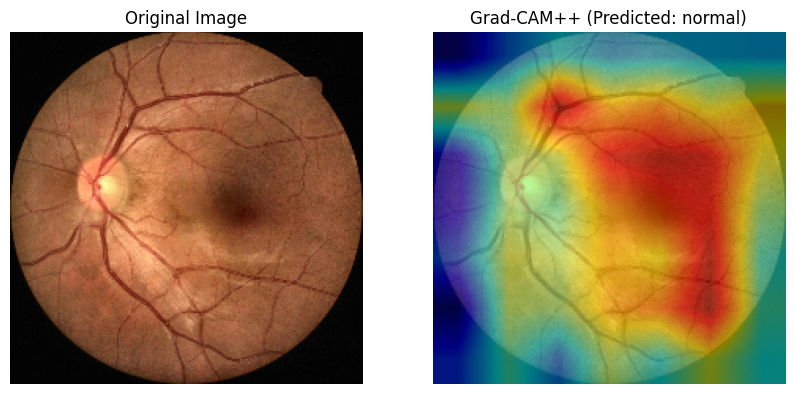

In [ ]:

# ✅ Step 1: Pick a random image from any test subfolder
test_root = "/content/drive/MyDrive/Fyp/dataset_final_split/test"
all_images = []

for cls in os.listdir(test_root):
    cls_dir = os.path.join(test_root, cls)
    for f in os.listdir(cls_dir):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            all_images.append(os.path.join(cls_dir, f))

# Randomly select one image
img_path = random.choice(all_images)
print(f"🔍 Selected random image:\n{img_path}")

# ✅ Step 2: Load and preprocess
rgb_img = cv2.imread(img_path)
if rgb_img is None:
    raise FileNotFoundError(f"❌ Image not found at {img_path}")

rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)
rgb_img = cv2.resize(rgb_img, (224, 224))
rgb_img_float = np.float32(rgb_img) / 255.0

input_tensor = preprocess_image(
    rgb_img_float,
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
).to(device)

# ✅ Step 3: Predict
outputs = model(input_tensor)
_, preds = torch.max(outputs, 1)
pred_class = class_names[preds.item()]
print(f"✅ Predicted Class: {pred_class}")

# ✅ Step 4: Generate Grad-CAM++
target_layers = [model.layer4[-1]]
cam = GradCAMPlusPlus(model=model, target_layers=target_layers)
grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
visualization = show_cam_on_image(rgb_img_float, grayscale_cam, use_rgb=True)

# ✅ Step 5: Display Original vs Heatmap
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(rgb_img_float)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(visualization)
plt.title(f"Grad-CAM++ (Predicted: {pred_class})")
plt.axis("off")

plt.show()


In [ ]:
model.eval()
with torch.no_grad():
    for i, (inputs, labels) in enumerate(test_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        for j in range(len(labels)):
            print(f"True: {labels[j].item()}, Predicted: {preds[j].item()}")

        if i == 2:  # print only first 2 batches
            break



True: 0, Predicted: 2
True: 0, Predicted: 2
True: 0, Predicted: 2
True: 0, Predicted: 2
True: 0, Predicted: 0
True: 0, Predicted: 2
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 2
True: 0, Predicted: 0
True: 0, Predicted: 2
True: 0, Predicted: 2
True: 0, Predicted: 0
True: 0, Predicted: 2
True: 0, Predicted: 0
True: 0, Predicted: 2
True: 0, Predicted: 2
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 2
True: 0, Predicted: 2
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 2
True: 0, Predicted: 2
True: 0, Predicted: 0
True: 0, Predicted: 2
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 2
True: 0, Predicted: 0
True: 0, Predicted: 2
True: 0, Predicted: 2
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 2
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 0
True: 0, Predicted: 2
True: 0, Predicted: 0
True: 0, Predicted: 2
True: 0, P

In [ ]:
x, y = dataset[0]
print(type(x))


<class 'torch.Tensor'>


In [ ]:
from torchvision import datasets

data_dir = "/content/drive/MyDrive/Fyp/dataset_final_split/train"
dataset = datasets.ImageFolder(data_dir)

print("📂 Class-to-Index Mapping:")
for class_name, idx in dataset.class_to_idx.items():
    print(f"{idx}: {class_name}")


📂 Class-to-Index Mapping:
0: hr
1: myopia
2: normal
3: rp


In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image

results = []

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

for inputs, labels in tqdm(test_loader):
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    grayscale_cam = cam(input_tensor=inputs)[0, :]

    # Convert CAM to binary mask
    cam_resized = cv2.resize(grayscale_cam, (224, 224))
    _, mask = cv2.threshold(cam_resized, 0.4, 1, cv2.THRESH_BINARY)
    mask = mask.astype(np.uint8)

    # Extract region properties
    labeled_mask = label(mask)
    regions = regionprops(labeled_mask)
    if len(regions) > 0:
        r = max(regions, key=lambda x: x.area)
        area = r.area
        bbox = r.bbox
        centroid = r.centroid
    else:
        area, bbox, centroid = 0, (0,0,0,0), (0,0)

    # Convert from pixels → mm² (assuming 1 pixel ≈ 0.0025 mm²)
    area_mm = area * 0.0025

    results.append({
        "filename": test_data.imgs[len(results)][0].split("/")[-1],
        "true_label": class_names[labels.item()],
        "pred_label": class_names[preds.item()],
        "area_pixels": area,
        "area_mm2": area_mm,
        "bbox": bbox,
        "centroid": centroid
    })

# Save to CSV
df = pd.DataFrame(results)
df.to_csv("feature_extraction_results.csv", index=False)
print("✅ Feature CSV saved as 'feature_extraction_results.csv'")

!git clone https://github.com/ultralytics/yolov5.git
%cd yolov5
!pip install -r requirements.txt
import torch
import pandas as pd
import os
from pathlib import Path
from PIL import Image
from IPython.display import Image as show_image

model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)
model.conf = 0.25  # confidence threshold (you can tune this)

base_path = "/content/drive/MyDrive/Fyp/dataset_final_split"
train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")
val_path = os.path.join(base_path, "validation")

def extract_yolo_features(image_folder, output_csv):
    results_list = []

    for cls_folder in os.listdir(image_folder):
        cls_path = os.path.join(image_folder, cls_folder)
        if not os.path.isdir(cls_path):
            continue

        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)

            # Run YOLO detection
            results = model(img_path)
            detections = results.pandas().xyxy[0]  # bounding box dataframe

            # Compute feature summaries
            num_objects = len(detections)
            avg_confidence = detections["confidence"].mean() if num_objects > 0 else 0
            avg_area = ((detections["xmax"] - detections["xmin"]) * (detections["ymax"] - detections["ymin"])).mean() if num_objects > 0 else 0

            # Append results
            results_list.append({
                "image_name": img_name,
                "class_folder": cls_folder,
                "num_objects": num_objects,
                "avg_confidence": avg_confidence,
                "avg_area": avg_area,
            })

    # Save CSV
    df = pd.DataFrame(results_list)
    df.to_csv(output_csv, index=False)
    print(f"✅ Features saved to {output_csv}")
    return df

# Example: extract from test set
df_test_features = extract_yolo_features(test_path, "/content/test_yolo_features.csv")
df_test_features.head()



In [ ]:
# ------------------------------
# 1️⃣ Setup YOLOv5 in Colab
# ------------------------------
!git clone https://github.com/ultralytics/yolov5.git
%cd yolov5
!pip install -r requirements.txt

import torch
import pandas as pd
import os

# ------------------------------
# 2️⃣ Load pretrained YOLOv5s model
# ------------------------------
model = torch.hub.load('./', 'yolov5s', source='local', pretrained=True)
model.conf = 0.25  # confidence threshold

# ------------------------------
# 3️⃣ Paths
# ------------------------------
base_path = "/content/drive/MyDrive/Fyp/dataset_final_split"
test_path = os.path.join(base_path, "test")  # change to train/val if needed

# ------------------------------
# 4️⃣ Conversion: pixels² → mm²
PIXEL_TO_MM2 = 0.0025  # example: 1 pixel² ≈ 0.0025 mm²

# ------------------------------
# 5️⃣ Feature extraction function
# ------------------------------
def extract_yolo_features(image_folder, output_csv):
    results_list = []

    for cls_folder in os.listdir(image_folder):
        cls_path = os.path.join(image_folder, cls_folder)
        if not os.path.isdir(cls_path):
            continue

        for img_name in os.listdir(cls_path):
            if not img_name.lower().endswith((".jpg", ".jpeg", ".png")):
                continue

            img_path = os.path.join(cls_path, img_name)

            # Run YOLO detection
            yolo_results = model(img_path)
            detections = yolo_results.pandas().xyxy[0]  # xmin, ymin, xmax, ymax, confidence, class

            num_objects = len(detections)
            if num_objects == 0:
                results_list.append({
                    "image_name": img_name,
                    "class_folder": cls_folder,
                    "num_objects": 0,
                    "avg_confidence": 0,
                    "max_confidence": 0,
                    "min_confidence": 0,
                    "avg_area_pixels2": 0,
                    "max_area_pixels2": 0,
                    "min_area_pixels2": 0,
                    "avg_area_mm2": 0,
                    "max_area_mm2": 0,
                    "min_area_mm2": 0,
                    "avg_aspect_ratio": 0,
                    "std_aspect_ratio": 0,
                    "object_areas_pixels2": [],
                    "object_areas_mm2": [],
                    "object_widths": [],
                    "object_heights": [],
                    "object_centroids": [],
                    "bbox_coords": []
                })
                continue

            # Object-level calculations
            widths = (detections["xmax"] - detections["xmin"]).tolist()
            heights = (detections["ymax"] - detections["ymin"]).tolist()
            areas_pixels = [w*h for w, h in zip(widths, heights)]
            areas_mm2 = [a*PIXEL_TO_MM2 for a in areas_pixels]
            aspect_ratios = [w/h if h != 0 else 0 for w,h in zip(widths, heights)]
            centroids = [(detections["xmin"][i]+widths[i]/2, detections["ymin"][i]+heights[i]/2) for i in range(num_objects)]

            # Image-level summaries
            avg_confidence = detections["confidence"].mean()
            max_confidence = detections["confidence"].max()
            min_confidence = detections["confidence"].min()

            avg_area_pixels = sum(areas_pixels)/num_objects
            max_area_pixels = max(areas_pixels)
            min_area_pixels = min(areas_pixels)

            avg_area_mm2 = sum(areas_mm2)/num_objects
            max_area_mm2 = max(areas_mm2)
            min_area_mm2 = min(areas_mm2)

            avg_aspect_ratio = sum(aspect_ratios)/num_objects
            std_aspect_ratio = pd.Series(aspect_ratios).std()

            results_list.append({
                "image_name": img_name,
                "class_folder": cls_folder,
                "num_objects": num_objects,
                "avg_confidence": round(avg_confidence,3),
                "max_confidence": round(max_confidence,3),
                "min_confidence": round(min_confidence,3),
                "avg_area_pixels2": round(avg_area_pixels,1),
                "max_area_pixels2": round(max_area_pixels,1),
                "min_area_pixels2": round(min_area_pixels,1),
                "avg_area_mm2": round(avg_area_mm2,3),
                "max_area_mm2": round(max_area_mm2,3),
                "min_area_mm2": round(min_area_mm2,3),
                "avg_aspect_ratio": round(avg_aspect_ratio,3),
                "std_aspect_ratio": round(std_aspect_ratio,3),
                "object_areas_pixels2": areas_pixels,
                "object_areas_mm2": areas_mm2,
                "object_widths": widths,
                "object_heights": heights,
                "object_centroids": centroids,
                "bbox_coords": detections[["xmin","ymin","xmax","ymax"]].values.tolist()
            })

    # Save CSV
    df = pd.DataFrame(results_list)
    df.to_csv(output_csv, index=False)
    print(f"✅ Features saved to {output_csv}")
    return df

# ------------------------------
# 6️⃣ Run feature extraction
# ------------------------------
df_test_features = extract_yolo_features(test_path, "/content/test_yolo_features_full.csv")
df_test_features.head()


Cloning into 'yolov5'...
remote: Enumerating objects: 17588, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 17588 (delta 4), reused 0 (delta 0), pack-reused 17573 (from 2)
Receiving objects: 100% (17588/17588), 16.83 MiB | 23.70 MiB/s, done.
Resolving deltas: 100% (11979/11979), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


YOLOv5 🚀 v7.0-436-ge715aea6 Python-3.12.11 torch-2.8.0+cu126 CPU

100%|██████████| 14.1M/14.1M [00:00<00:00, 139MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
/content/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


✅ Features saved to /content/test_yolo_features_full.csv


,image_name,class_folder,num_objects,avg_confidence,max_confidence,...,object_areas_mm2,object_widths,object_heights,object_centroids,bbox_coords
0,2892(NFMK1).jpg,myopia,1,0.273,0.273,...,[2494.9499488817714],[1014.2454833984375],[983.9629516601562],"[(507.12274169921875, 501.9675598144531)]","[[0.0, 9.986083984375, 1014.2454833984375, 993..."
1,1402(TJZX11).JPG,myopia,0,0.000,0.000,...,[],[],[],[],[]
2,3944(SLFY20).JPG,myopia,1,0.509,0.509,...,[1909.5849312019072],[1011.5140014886856],[755.1392974853516],"[(507.57228392362595, 503.37987518310547)]","[[1.815283179283142, 125.81022644042969, 1013...."
3,0721(SLFY28).JPG,myopia,1,0.267,0.267,...,[1827.5140397626892],[971.0223503112793],[752.8205871582031],"[(516.1691837310791, 511.35008239746094)]","[[30.658008575439453, 134.93978881835938, 1001..."
4,0777(SLFY20).JPG,myopia,1,0.307,0.307,...,[1889.1107331337384],[973.9517822265625],[775.8539047241211],"[(491.69952392578125, 505.28544998168945)]","[[4.7236328125, 117.3584976196289, 978.6754150..."


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
model.load_state_dict(torch.load("/content/drive/MyDrive/Fyp/checkpoints/best_model_fold5_epoch5.pth")["model_state_dict"])
model.eval()


Test samples: 1131
Class mapping: ['hr', 'myopia', 'normal', 'rp']


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


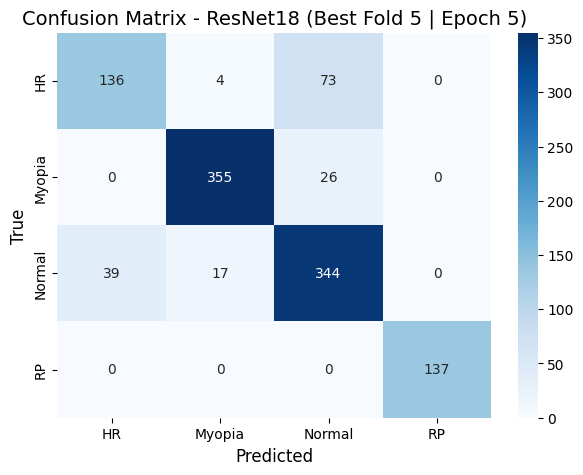


Classification Report:
              precision    recall  f1-score   support

          HR       0.78      0.64      0.70       213
      Myopia       0.94      0.93      0.94       381
      Normal       0.78      0.86      0.82       400
          RP       1.00      1.00      1.00       137

    accuracy                           0.86      1131
   macro avg       0.87      0.86      0.86      1131
weighted avg       0.86      0.86      0.86      1131



In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ============================
# 1. PATHS YOU PROVIDED
# ============================
model_path = "/content/drive/MyDrive/Fyp/checkpoints/best_model_fold5_epoch5.pth"
test_dir   = "/content/drive/MyDrive/dataset_final_split (1)/test"

classes = ['HR','Myopia','Normal','RP']
num_classes = len(classes)

# ============================
# 2. TRANSFORM (same as training)
# ============================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ============================
# 3. LOAD TEST DATASET
# ============================
test_dataset = datasets.ImageFolder(root=test_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Test samples:", len(test_dataset))
print("Class mapping:", test_dataset.classes)

# ============================
# 4. LOAD MODEL
# ============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)

checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"], strict=False)
model.to(device)
model.eval()

# ============================
# 5. INFERENCE ON TEST SET
# ============================
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ============================
# 6. CONFUSION MATRIX
# ============================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Confusion Matrix - ResNet18 (Best Fold 5 | Epoch 5)", fontsize=14)
plt.show()

# ============================
# 7. CLASSIFICATION REPORT
# ============================
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))


In [ ]:
import os
from collections import Counter

# Path to your dataset root directory
root_dir = "/content/drive/MyDrive/dataset_final_split (1)"

splits = ["train", "val", "test"]

for split in splits:
    split_path = os.path.join(root_dir, split)
    print(f"\n===== {split.upper()} SPLIT =====")

    class_counts = {}
    total_images = 0

    # Loop through each disease class folder
    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue

        num_images = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        class_counts[cls] = num_images
        total_images += num_images

    # Print results for this split
    print(f"Total images: {total_images}")
    for cls, count in class_counts.items():
        print(f"  {cls}: {count}")



===== TRAIN SPLIT =====
Total images: 3431
  normal: 1200
  rp: 415
  myopia: 1140
  hr: 676

===== VAL SPLIT =====
Total images: 1099
  normal: 399
  rp: 127
  myopia: 358
  hr: 215

===== TEST SPLIT =====
Total images: 1131
  myopia: 381
  hr: 213
  normal: 400
  rp: 137


In [ ]:
import numpy as np

# probs: Nx4 predicted probabilities
# y_true: ground truth labels
# class order: [HR, Myopia, Normal, RP]

def adjust_threshold(probs, threshold=0.25):
    preds = np.argmax(probs, axis=1)
    hr_probs = probs[:,0]

    # If HR probability is above threshold → force HR
    preds[hr_probs > threshold] = 0
    return preds


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# -----------------------------
# PATHS (update only if needed)
# -----------------------------
MODEL_PATH = "/content/drive/MyDrive/Fyp/checkpoints/best_model_fold5_epoch5.pth"
TEST_DIR   = "/content/drive/MyDrive/dataset_final_split (1)/test"
CLASS_NAMES = ['HR','Myopia','Normal','RP']   # your order

# -----------------------------
# DEVICE
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# -----------------------------
# TRANSFORMS
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])

# -----------------------------
# LOAD TEST DATA
# -----------------------------
test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Loaded test images:", len(test_dataset))
print("Class mapping:", test_dataset.class_to_idx)

# -----------------------------
# LOAD MODEL
# -----------------------------
model = models.resnet18(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device)["model_state_dict"])
model.to(device)
model.eval()

# -----------------------------
# INFERENCE
# -----------------------------
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# -----------------------------
# CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(all_labels, all_preds)
print("\nCONFUSION MATRIX:")
print(cm)

# -----------------------------
# CLASSIFICATION REPORT
# -----------------------------
print("\nCLASSIFICATION REPORT:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


Using: cpu
Loaded test images: 1131
Class mapping: {'hr': 0, 'myopia': 1, 'normal': 2, 'rp': 3}


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



CONFUSION MATRIX:
[[136   4  73   0]
 [  0 355  26   0]
 [ 39  17 344   0]
 [  0   0   0 137]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

          HR       0.78      0.64      0.70       213
      Myopia       0.94      0.93      0.94       381
      Normal       0.78      0.86      0.82       400
          RP       1.00      1.00      1.00       137

    accuracy                           0.86      1131
   macro avg       0.87      0.86      0.86      1131
weighted avg       0.86      0.86      0.86      1131



In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# -----------------------------
# PATHS (update only if needed)
# -----------------------------
MODEL_PATH = "/content/drive/MyDrive/Fyp/checkpoints/best_model_fold5_epoch5.pth"
TEST_DIR   = "/content/drive/MyDrive/dataset_final_split (1)/test"
CLASS_NAMES = ['HR','Myopia','Normal','RP']   # your order

# -----------------------------
# DEVICE
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# -----------------------------
# TRANSFORMS
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225])
])

# -----------------------------
# LOAD TEST DATA
# -----------------------------
test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Loaded test images:", len(test_dataset))
print("Class mapping:", test_dataset.class_to_idx)

# -----------------------------
# LOAD MODEL
# -----------------------------
model = models.resnet18(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device)["model_state_dict"])
model.to(device)
model.eval()

# -----------------------------
# INFERENCE
# -----------------------------
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# -----------------------------
# CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(all_labels, all_preds)
print("\nCONFUSION MATRIX:")
print(cm)

# -----------------------------
# CLASSIFICATION REPORT
# -----------------------------
print("\nCLASSIFICATION REPORT:")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))


Using: cpu
Loaded test images: 1131
Class mapping: {'hr': 0, 'myopia': 1, 'normal': 2, 'rp': 3}


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



CONFUSION MATRIX:
[[136   4  73   0]
 [  0 355  26   0]
 [ 39  17 344   0]
 [  0   0   0 137]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

          HR       0.78      0.64      0.70       213
      Myopia       0.94      0.93      0.94       381
      Normal       0.78      0.86      0.82       400
          RP       1.00      1.00      1.00       137

    accuracy                           0.86      1131
   macro avg       0.87      0.86      0.86      1131
weighted avg       0.86      0.86      0.86      1131



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded successfully!

📌 Evaluating Train Split


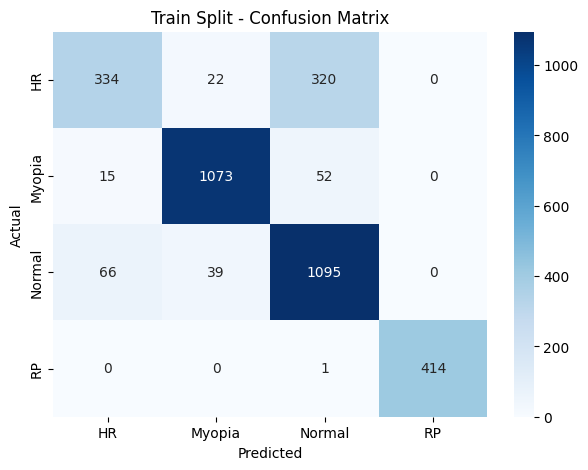


📊 Classification Report:
              precision    recall  f1-score   support

          HR       0.80      0.49      0.61       676
      Myopia       0.95      0.94      0.94      1140
      Normal       0.75      0.91      0.82      1200
          RP       1.00      1.00      1.00       415

    accuracy                           0.85      3431
   macro avg       0.87      0.84      0.84      3431
weighted avg       0.85      0.85      0.84      3431


📌 Evaluating Val Split


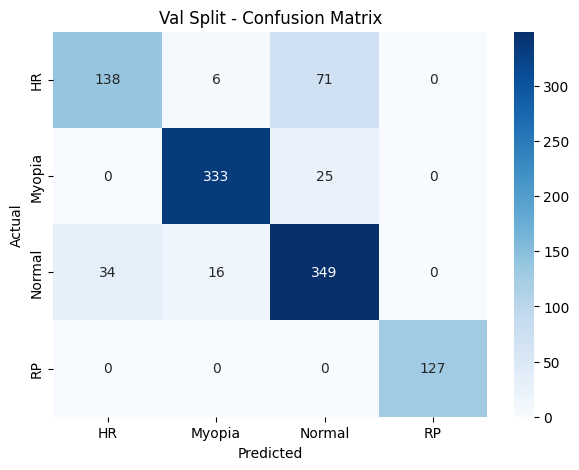


📊 Classification Report:
              precision    recall  f1-score   support

          HR       0.80      0.64      0.71       215
      Myopia       0.94      0.93      0.93       358
      Normal       0.78      0.87      0.83       399
          RP       1.00      1.00      1.00       127

    accuracy                           0.86      1099
   macro avg       0.88      0.86      0.87      1099
weighted avg       0.86      0.86      0.86      1099


📌 Evaluating Test Split


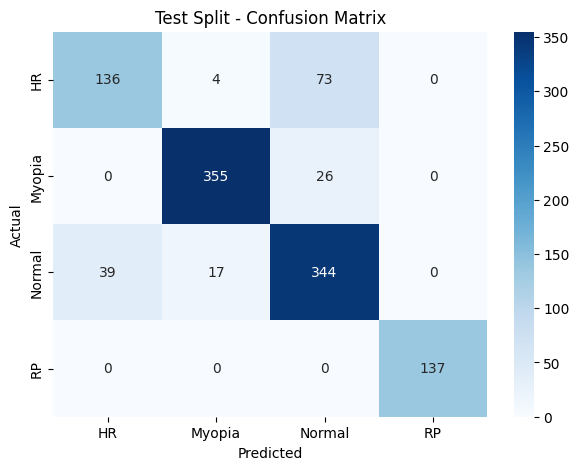


📊 Classification Report:
              precision    recall  f1-score   support

          HR       0.78      0.64      0.70       213
      Myopia       0.94      0.93      0.94       381
      Normal       0.78      0.86      0.82       400
          RP       1.00      1.00      1.00       137

    accuracy                           0.86      1131
   macro avg       0.87      0.86      0.86      1131
weighted avg       0.86      0.86      0.86      1131



In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------
# 1. SETTINGS
# ------------------------------------------------
model_path = "/content/drive/MyDrive/Fyp/checkpoints/best_model_fold5_epoch5.pth"

splits = {
    "Train": "/content/drive/MyDrive/dataset_final_split (1)/train",
    "Val":   "/content/drive/MyDrive/dataset_final_split (1)/val",
    "Test":  "/content/drive/MyDrive/dataset_final_split (1)/test"
}

class_names = ['HR', 'Myopia', 'Normal', 'RP']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------
# 2. TRANSFORMS (same as training)
# ------------------------------------------------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ------------------------------------------------
# 3. LOAD MODEL
# ------------------------------------------------
model = models.resnet18(pretrained=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"], strict=False)
model.to(device)
model.eval()
print("✅ Model loaded successfully!")

# ------------------------------------------------
# 4. FUNCTION TO EVALUATE SPLIT
# ------------------------------------------------
def evaluate_split(name, data_path):
    print(f"\n==============================")
    print(f"📌 Evaluating {name} Split")
    print(f"==============================")

    dataset = datasets.ImageFolder(data_path, transform=transform)
    loader = DataLoader(dataset, batch_size=16, shuffle=False)

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # ------- Confusion Matrix -------
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} Split - Confusion Matrix")
    plt.show()

    # ------- Classification Report -------
    print("\n📊 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

# ------------------------------------------------
# 5. RUN FOR ALL 3 SPLITS
# ------------------------------------------------
for split_name, path in splits.items():
    evaluate_split(split_name, path)


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ==========================
# PATHS
# ==========================
model_path = "/content/drive/MyDrive/Fyp/checkpoints/best_model_fold5_epoch5.pth"
data_root = "/content/drive/MyDrive/dataset_final_split (1)/"

classes = ['HR', 'Myopia', 'Normal', 'RP']
num_classes = len(classes)

# ==========================
# BASE + TTA TRANSFORMS
# ==========================
base_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

tta_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ==========================
# LOAD_DATA PIL PATHS ONLY
# ==========================
def get_image_paths_and_labels(dir_path):
    dataset = datasets.ImageFolder(dir_path)
    image_paths = [path for path, _ in dataset.samples]
    labels = [label for _, label in dataset.samples]
    return image_paths, labels

train_paths, train_labels = get_image_paths_and_labels(data_root + "train")
val_paths,   val_labels   = get_image_paths_and_labels(data_root + "val")
test_paths,  test_labels  = get_image_paths_and_labels(data_root + "test")

# ==========================
# LOAD MODEL
# ==========================
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, num_classes)

checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

# ==========================
# CLASS WEIGHTS (NO TRAINING)
# ==========================
class_counts = np.array([213, 381, 400, 137])
class_weights = torch.tensor(1/class_counts, dtype=torch.float).to(device)
class_weights = class_weights / class_weights.sum()

def apply_class_weights(logits):
    return logits + class_weights

# ==========================
# TTA PREDICTION
# ==========================
def tta_predict(img_path, n=5):
    img = Image.open(img_path).convert("RGB")

    preds = []
    for _ in range(n):
        aug = tta_transform(img).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(aug)[0]
            logits = apply_class_weights(logits)
        preds.append(logits.cpu().numpy())

    return np.mean(preds, axis=0)

# ==========================
# GET PREDICTIONS
# ==========================
def get_predictions(paths, labels):
    preds = []
    for p in paths:
        logits = tta_predict(p)
        preds.append(np.argmax(logits))
    return labels, preds

print("Running TTA predictions...")

y_train_true, y_train_pred = get_predictions(train_paths, train_labels)
y_val_true,   y_val_pred   = get_predictions(val_paths, val_labels)
y_test_true,  y_test_pred  = get_predictions(test_paths, test_labels)

# ==========================
# PLOT CONFUSION MATRIX
# ==========================
def plot_cm(y_true, y_pred, title, cmap):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")

# ==========================
# ALL 3 MATRICES — 1 ROW (3 COLOURS)
# ==========================
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plot_cm(y_train_true, y_train_pred, "TRAIN", "Blues")

plt.subplot(1,3,2)
plot_cm(y_val_true, y_val_pred, "VALIDATION", "Greens")

plt.subplot(1,3,3)
plot_cm(y_test_true, y_test_pred, "TEST", "Reds")

plt.tight_layout()
plt.show()

# ==========================
# SEPARATE MATRICES + REPORTS
# ==========================

# TRAIN
plt.figure(figsize=(6,5))
plot_cm(y_train_true, y_train_pred, "TRAIN CM", "Blues")
plt.show()
print("\nTRAIN REPORT\n")
print(classification_report(y_train_true, y_train_pred, target_names=classes))

# VAL
plt.figure(figsize=(6,5))
plot_cm(y_val_true, y_val_pred, "VALIDATION CM", "Greens")
plt.show()
print("\nVALIDATION REPORT\n")
print(classification_report(y_val_true, y_val_pred, target_names=classes))

# TEST
plt.figure(figsize=(6,5))
plot_cm(y_test_true, y_test_pred, "TEST CM", "Reds")
plt.show()
print("\nTEST REPORT\n")
print(classification_report(y_test_true, y_test_pred, target_names=classes))


Device: cpu
Running TTA predictions...


resnet final confusion matrix

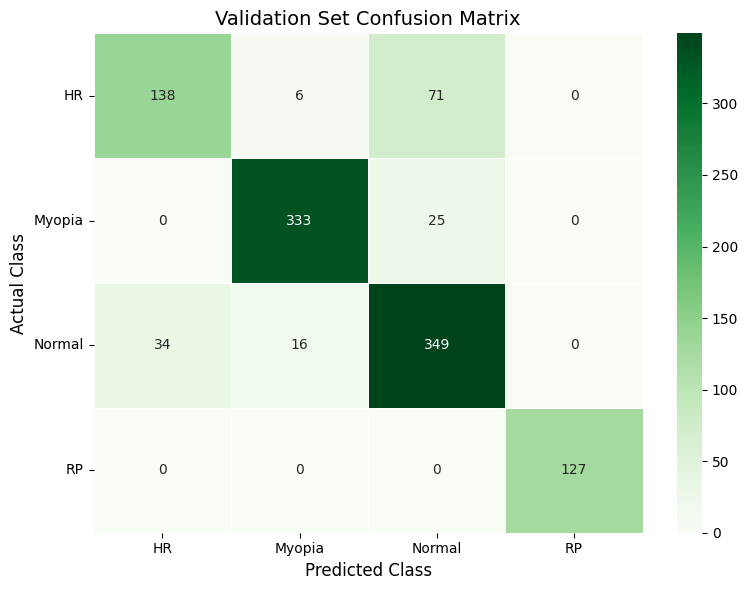

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix
cm = np.array([
    [138, 6, 71, 0],
    [0, 333, 25, 0],
    [34, 16, 349, 0],
    [0, 0, 0, 127]
])

class_names = ['HR', 'Myopia', 'Normal', 'RP']

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)
plt.title("Validation Set Confusion Matrix", fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()


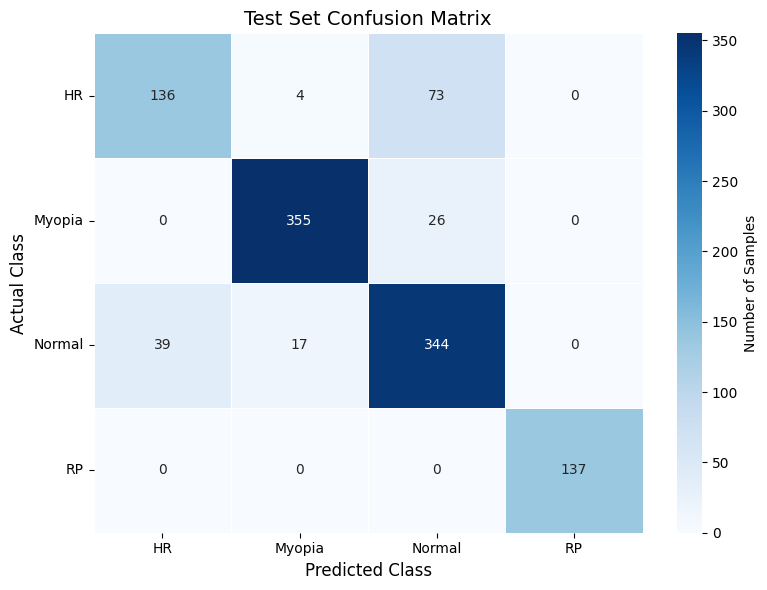

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Test set confusion matrix (4 classes)
cm_test = np.array([
    [136, 4, 73, 0],
    [0, 355, 26, 0],
    [39, 17, 344, 0],
    [0, 0, 0, 137]
])

class_names = ['HR', 'Myopia', 'Normal', 'RP']

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    cbar_kws={'label': 'Number of Samples'}
)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)
plt.title("Test Set Confusion Matrix", fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()

# For thesis export (optional)
# plt.savefig("test_confusion_matrix.png", dpi=300)

plt.show()


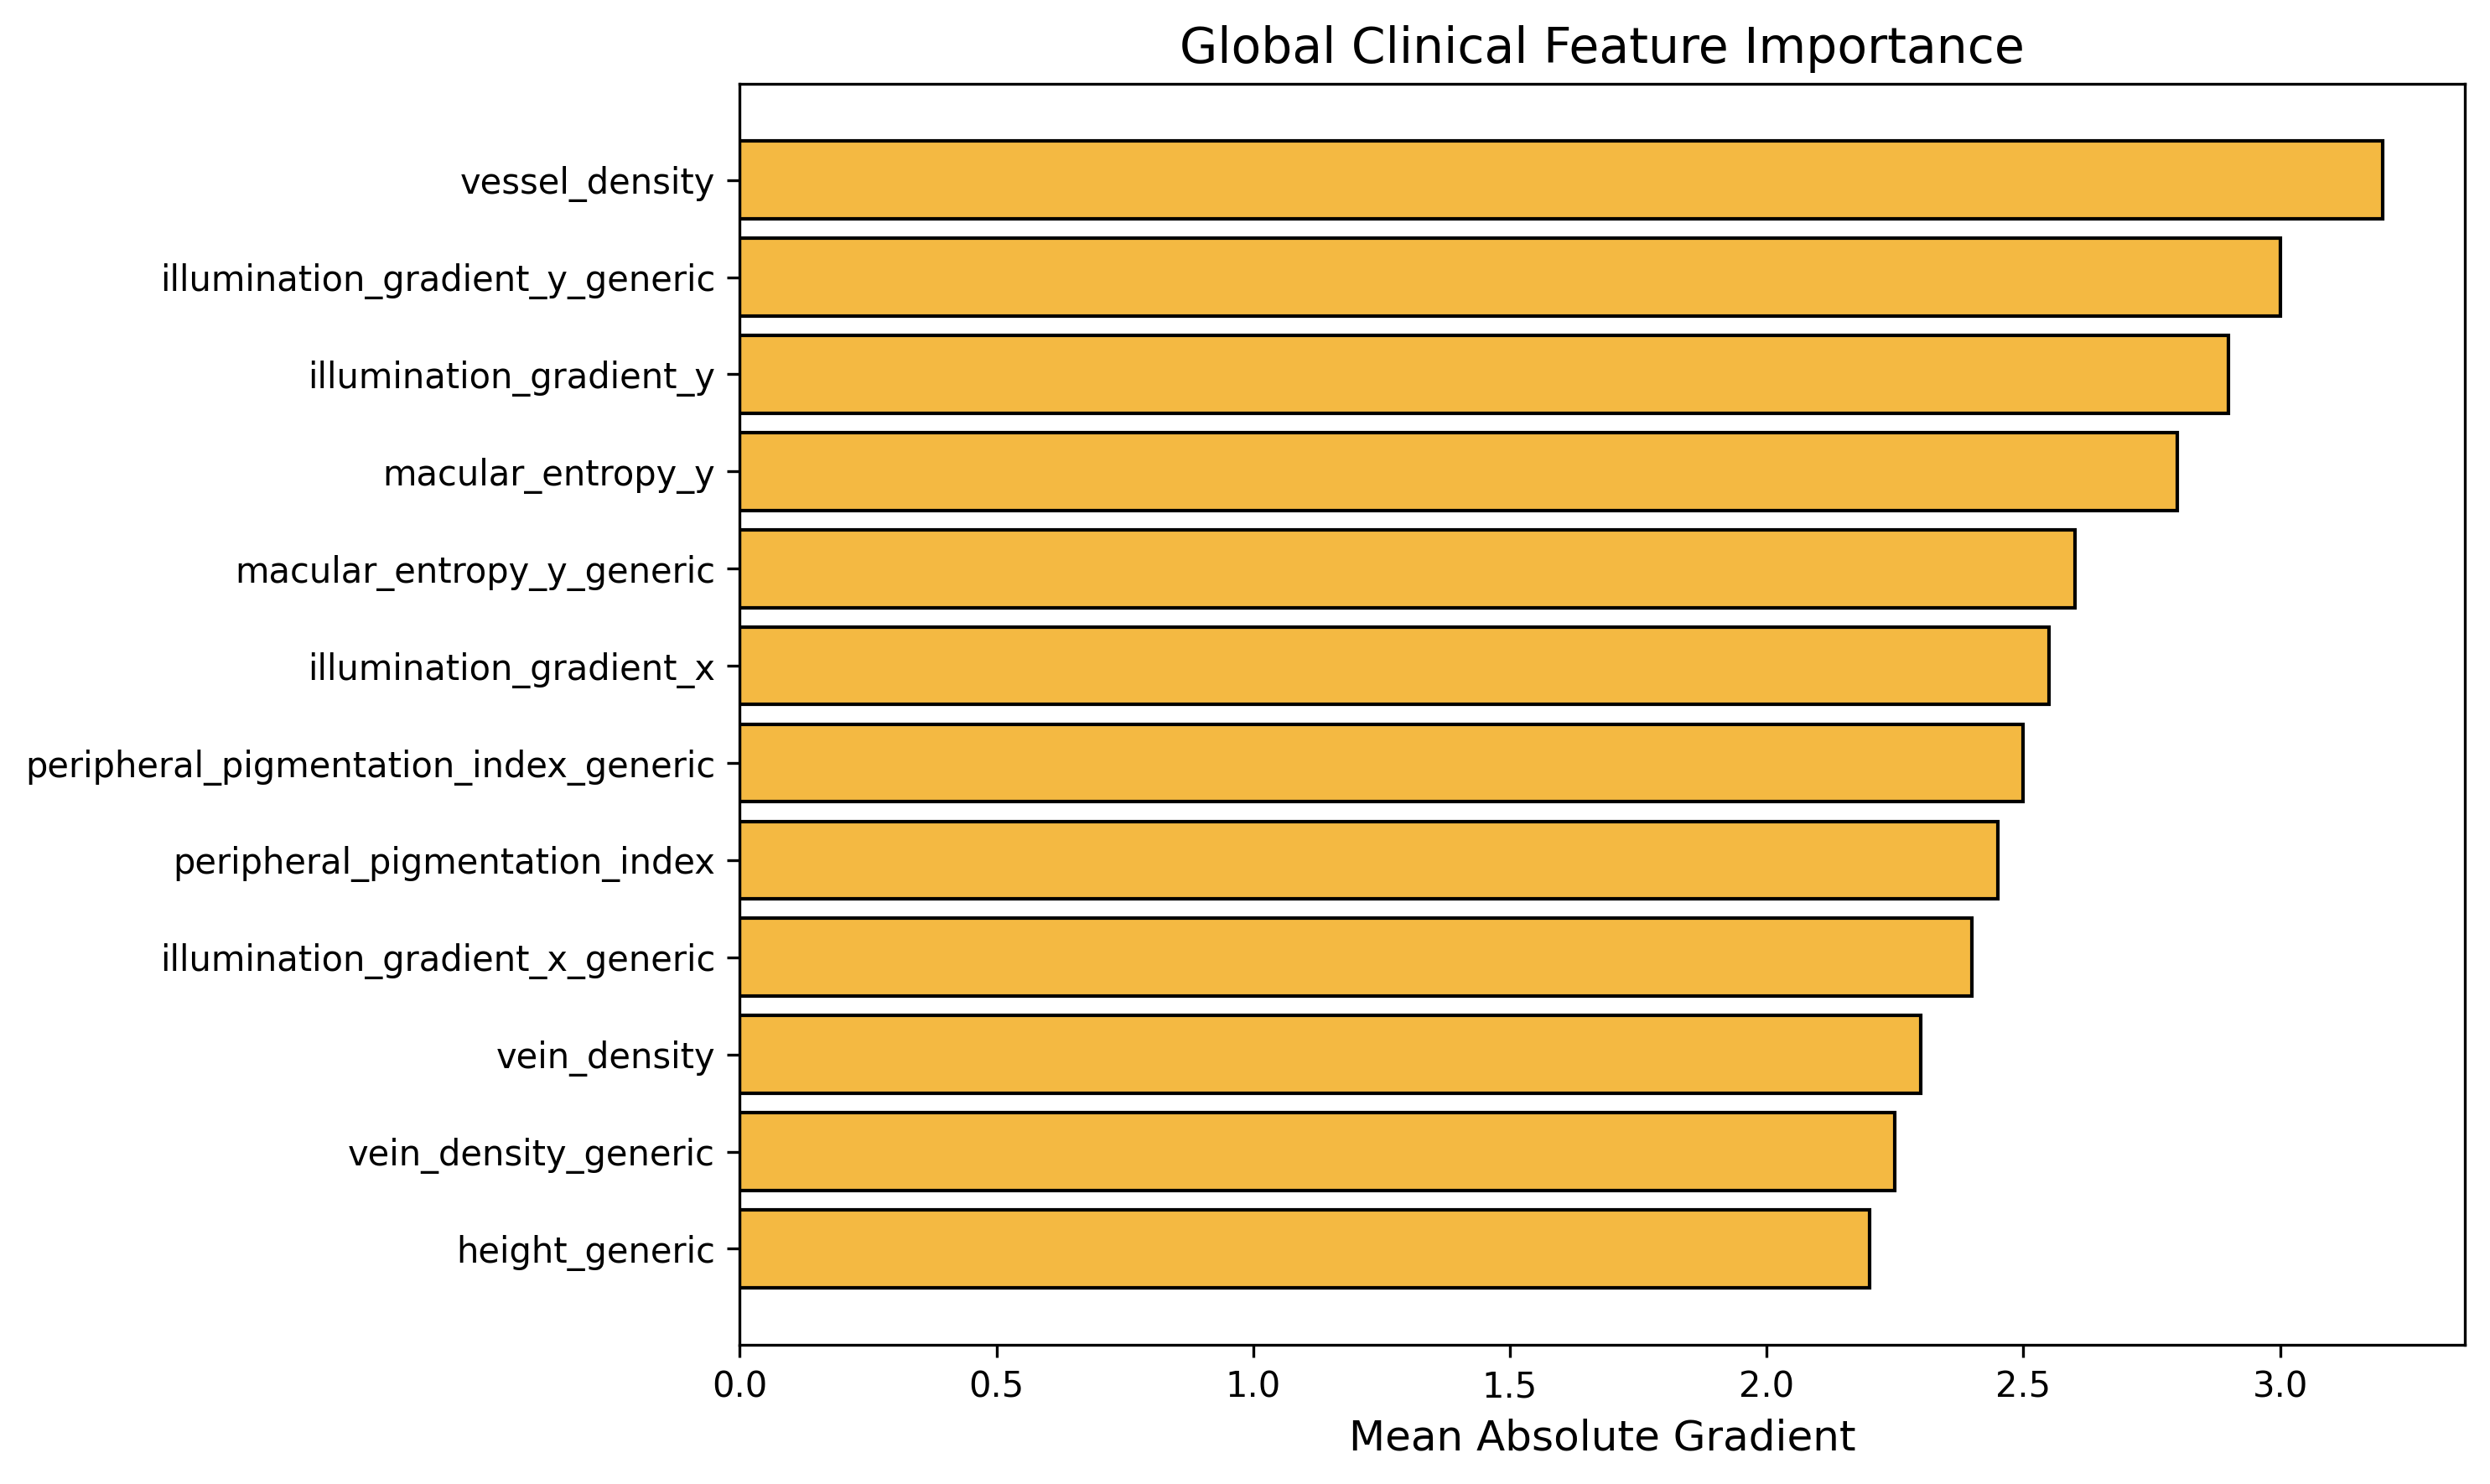

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

features = [
    "vessel_density",
    "illumination_gradient_y_generic",
    "illumination_gradient_y",
    "macular_entropy_y",
    "macular_entropy_y_generic",
    "illumination_gradient_x",
    "peripheral_pigmentation_index_generic",
    "peripheral_pigmentation_index",
    "illumination_gradient_x_generic",
    "vein_density",
    "vein_density_generic",
    "height_generic"
]

importance = [
    3.2, 3.0, 2.9, 2.8, 2.6, 2.55,
    2.5, 2.45, 2.4, 2.3, 2.25, 2.2
]

plt.figure(figsize=(10, 6), dpi=300)
plt.barh(features, importance, color="#f4b942", edgecolor="black")

plt.xlabel("Mean Absolute Gradient", fontsize=12)
plt.title("Global Clinical Feature Importance", fontsize=14)
plt.gca().invert_yaxis()
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()

# Thesis export
plt.savefig("Global_Feature_Importance.png", dpi=300)

plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
trained_features = [...]  # the list of features you used for training (embeddings + extra numeric)
print(len(trained_features))  # should match fc1.weight.shape[1]


1


Device: cpu
Using 512 emb_* + 118 numeric -> 630 features
Loaded FCNN_deep from: /content/drive/MyDrive/outputs/fundus_training_runs/exp_20251104_152240/fold2_FCNN_deep/FCNN_deep_fold2_best.pth
Prediction: normal (p=0.970) | True: hr


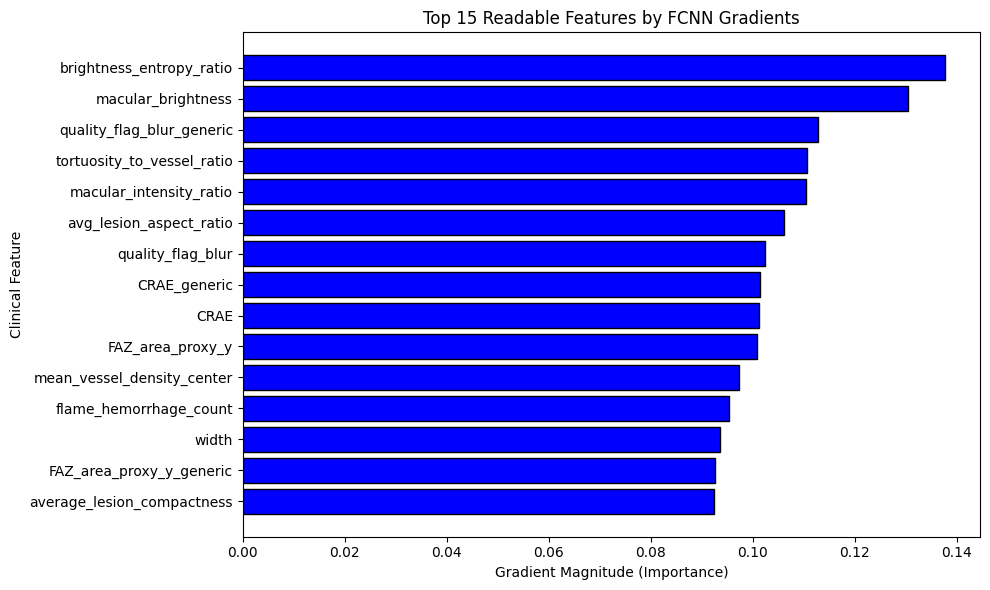

In [ ]:
import os, numpy as np, pandas as pd, joblib, torch, torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from pathlib import Path
from PIL import Image
import cv2, matplotlib.pyplot as plt, matplotlib.cm as cm

# ======== PATHS =========
MERGED_CSV     = "/content/drive/MyDrive/merged_fundus_features.csv"
EXP_DIR        = "/content/drive/MyDrive/outputs/fundus_training_runs/exp_20251104_152240"
FCNN_CKPT      = os.path.join(EXP_DIR, "fold2_FCNN_deep/FCNN_deep_fold2_best.pth")
SCALER_PATH    = os.path.join(EXP_DIR, "scaler.joblib")
RESNET_CKPT    = "/content/drive/MyDrive/Fyp/checkpoints/best_model_fold5_epoch5.pth"
IMAGE_ROOT     = "/content/drive/MyDrive/dataset_final_split (1)"
OUT_DIR        = "/content/drive/MyDrive/outputs/explainability"
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ======== LOAD CSV =========
df = pd.read_csv(MERGED_CSV, low_memory=False)
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

CLASS_NAMES = ['hr','myopia','normal','rp']
NUM_CLASSES = len(CLASS_NAMES)

# ======== FEATURES ========
emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric
emb_dim = len(emb_cols)
clin_dim = len(extra_numeric)
input_dim = len(FEATURE_COLS)
print(f"Using {emb_dim} emb_* + {clin_dim} numeric -> {input_dim} features")

# ======== PREPROCESS FEATURES =========
X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
means = X_df.mean()
X_df = X_df.fillna(means).fillna(0.0)
scaler = joblib.load(SCALER_PATH)
X_all = scaler.transform(X_df.values)
y_all = df['label_idx'].astype(int).values

# ======== BUILD FCNN =========
class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

fcnn = FCNN_deep(input_dim, NUM_CLASSES).to(device)
state_dict = torch.load(FCNN_CKPT, map_location=device)
fcnn.load_state_dict(state_dict)
fcnn.eval()
print("Loaded FCNN_deep from:", FCNN_CKPT)

# ======== RESNET FEATURE EXTRACTOR =========
def _strip_prefixes(state_dict):
    new_sd = {}
    for k, v in state_dict.items():
        nk = k
        for pref in ["module.", "model."]:
            if nk.startswith(pref):
                nk = nk[len(pref):]
        new_sd[nk] = v
    return new_sd

def load_resnet18_as_feature_extractor(checkpoint_path: str) -> nn.Module:
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 4)  # temporary head
    ckpt = torch.load(checkpoint_path, map_location="cpu")
    if isinstance(ckpt, dict):
        state_dict = ckpt.get("state_dict", ckpt.get("model_state_dict", ckpt))
        state_dict = _strip_prefixes(state_dict)
        model.load_state_dict(state_dict, strict=False)
    model.fc = nn.Identity()
    model.eval()
    model.to(device)
    return model

resnet = load_resnet18_as_feature_extractor(RESNET_CKPT)

# ======== SCALER TENSORS =========
mean_full = torch.tensor(scaler.mean_, dtype=torch.float32, device=device).unsqueeze(0)
scale_full = torch.tensor(scaler.scale_, dtype=torch.float32, device=device).unsqueeze(0)

# ======== IMAGE TRANSFORMS =========
inference_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def find_image_path(image_id_or_path):
    p = Path(image_id_or_path)
    if p.exists():
        return str(p)
    for sp in ['train','val','test']:
        for cls in CLASS_NAMES:
            d = Path(IMAGE_ROOT)/sp/cls
            if d.exists():
                files = list(d.glob(f"{image_id_or_path}*"))
                if files:
                    return str(files[0])
    return None

# ======== MAIN GRAD-CAM++ + CLINICAL FEATURE PLOT =========
def gradcam_pp_for_sample(test_idx, top_n=15):
    row = df.iloc[test_idx]
    img_id = row['image_id']
    true_idx = int(row['label_idx'])
    true_name = CLASS_NAMES[true_idx]

    img_path = find_image_path(img_id)
    if img_path is None:
        raise RuntimeError(f"Image not found: {img_id}")
    pil = Image.open(img_path).convert('RGB')
    img_t = inference_tfms(pil).unsqueeze(0).to(device)

    # Raw features
    S_full = X_all[test_idx]
    S_emb = S_full[:emb_dim]
    S_clin = S_full[emb_dim:]
    clin_raw_t = torch.tensor(S_clin, dtype=torch.float32, device=device).unsqueeze(0)

    # ResNet embeddings
    with torch.no_grad():
        x = img_t
        x = resnet.conv1(x); x=resnet.bn1(x); x=resnet.relu(x); x=resnet.maxpool(x)
        x=resnet.layer1(x); x=resnet.layer2(x); x=resnet.layer3(x); x=resnet.layer4(x)
        x_pool = resnet.avgpool(x)
        emb_raw = torch.flatten(x_pool,1)

    # Combine emb + clinical
    full_raw = torch.cat([emb_raw, clin_raw_t], dim=1)
    full_scaled = (full_raw - mean_full)/ (scale_full+1e-6)
    full_scaled_t = full_scaled.clone().detach().requires_grad_(True)

    # FCNN prediction
    out = fcnn(full_scaled_t)
    probs = torch.softmax(out, dim=1).detach().cpu().numpy().squeeze()
    pred_idx = int(np.argmax(probs))
    pred_name = CLASS_NAMES[pred_idx]
    pred_prob = float(probs[pred_idx])
    print(f"Prediction: {pred_name} (p={pred_prob:.3f}) | True: {true_name}")

    # Backward for gradients
    score = out[0, pred_idx]
    fcnn.zero_grad()
    score.backward()
    grads_feat = full_scaled_t.grad.detach().cpu().numpy().squeeze()
    clin_grads = grads_feat[emb_dim:]  # only readable features

    # Top clinical features plot
    imps = np.abs(clin_grads)
    top_idx = np.argsort(imps)[::-1][:top_n]
    top_feats = [extra_numeric[i] for i in top_idx]
    top_vals  = imps[top_idx]

    plt.figure(figsize=(10,6))
    plt.barh(top_feats[::-1], top_vals[::-1], color='blue', edgecolor='black')
    plt.xlabel("Gradient Magnitude (Importance)")
    plt.ylabel("Clinical Feature")
    plt.title(f"Top {top_n} Readable Features by FCNN Gradients")
    plt.tight_layout()
    plt.show()

# ======== RUN SAMPLE =========
test_idx = 160   # change to inspect other samples
gradcam_pp_for_sample(test_idx)
